In [ ]:
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
import librosa
from tqdm import tqdm
# SET PATH
os.chdir("D:/sound_project/Model")  # sửa nếu cần

In [46]:
X_urban = np.load("X_urban.npy")
y_urban = np.load("y_urban.npy")

X_esc50 = np.load("X_esc50.npy")
y_esc50 = np.load("y_esc50.npy")

print("Urban:", X_urban.shape)
print("ESC-50:", X_esc50.shape)

Urban: (8732, 13)
ESC-50: (2000, 13)


In [47]:
def preprocess_and_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

In [48]:
def plot_k_vs_accuracy(X, y, name):
    print(f"\n=== Tuning k cho {name} ===")

    k_values = range(1, 16)
    accuracies = []

    X_train, X_test, y_train, y_test = preprocess_and_split(X, y)

    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric='minkowski',
            p=2
        )
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    plt.figure()
    plt.plot(k_values, accuracies, marker='o')
    plt.title(f"K vs Accuracy - {name}")
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.tight_layout()
    plt.show()

    best_k = k_values[np.argmax(accuracies)]
    best_acc = max(accuracies)

    print(f"Best k: {best_k} | Accuracy: {round(best_acc,4)}")

    return best_k


In [ ]:
def run_knn(X, y, name="Dataset", k=5):
    print(f"\n===== {name} =====")

    print("Shape:", X.shape)
    print("Số class:", len(np.unique(y)))

    # giữ nguyên hàm của bạn
    X_train, X_test, y_train, y_test = preprocess_and_split(X, y)

    print("Train size:", X_train.shape[0])
    print("Test size:", X_test.shape[0])

    # ✅ THÊM SCALER
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ✅ LƯU MODEL + SCALER (FIX LỖI Ở ĐÂY)
    joblib.dump(knn, f"{name}_knn.pkl")
    joblib.dump(scaler, f"{name}_scaler.pkl")

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    # ESC-50 → chỉ màu
    if name == "ESC-50":
        sns.heatmap(cm, cmap="Blues", cbar=True)

    # UrbanSound8K → hiện số
    else:
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc


=== Tuning k cho UrbanSound8K ===


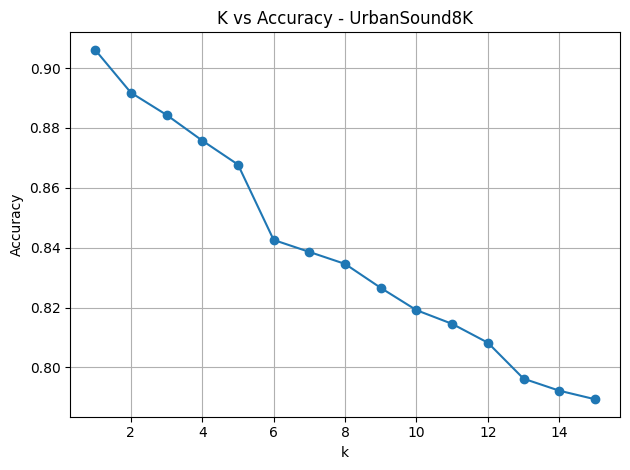

Best k: 1 | Accuracy: 0.9061

=== Tuning k cho ESC-50 ===


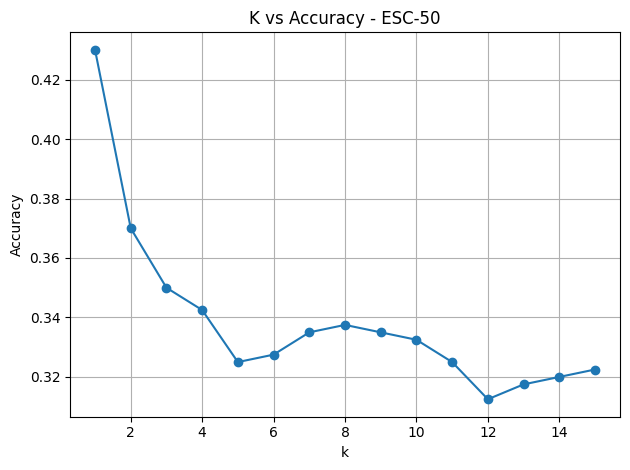

Best k: 1 | Accuracy: 0.43


In [50]:
k_urban = plot_k_vs_accuracy(X_urban, y_urban, "UrbanSound8K")
k_esc50 = plot_k_vs_accuracy(X_esc50, y_esc50, "ESC-50")

Kết quả tuning cho thấy k = 1 cho độ chính xác cao nhất trên cả hai tập dữ liệu. Tuy nhiên, giá trị k = 1 khiến mô hình phụ thuộc hoàn toàn vào một điểm dữ liệu gần nhất, do đó rất nhạy với nhiễu và có nguy cơ overfitting.

Quan sát biểu đồ cho thấy khi tăng k, accuracy giảm dần nhưng không giảm quá mạnh ở các giá trị nhỏ như k = 3 hoặc k = 5. Điều này cho thấy các giá trị k lớn hơn có thể mang lại sự ổn định tốt hơn trong dự đoán.

Vì vậy, mặc dù k = 1 cho kết quả cao nhất, nhóm cân nhắc sử dụng k = 3 hoặc k = 5 để đảm bảo khả năng tổng quát hóa của mô hình.


===== UrbanSound8K =====
Shape: (8732, 13)
Số class: 10
Train size: 6985
Test size: 1747
Accuracy: 0.9061

Classification Report:
                  precision    recall  f1-score   support

 air_conditioner       0.94      0.96      0.95       200
        car_horn       0.94      0.74      0.83        86
children_playing       0.85      0.88      0.86       200
        dog_bark       0.92      0.82      0.87       200
        drilling       0.93      0.94      0.93       200
   engine_idling       0.96      0.97      0.97       200
        gun_shot       0.81      0.76      0.79        75
      jackhammer       0.93      0.95      0.94       200
           siren       0.94      0.97      0.96       186
    street_music       0.81      0.88      0.84       200

        accuracy                           0.91      1747
       macro avg       0.90      0.89      0.89      1747
    weighted avg       0.91      0.91      0.91      1747



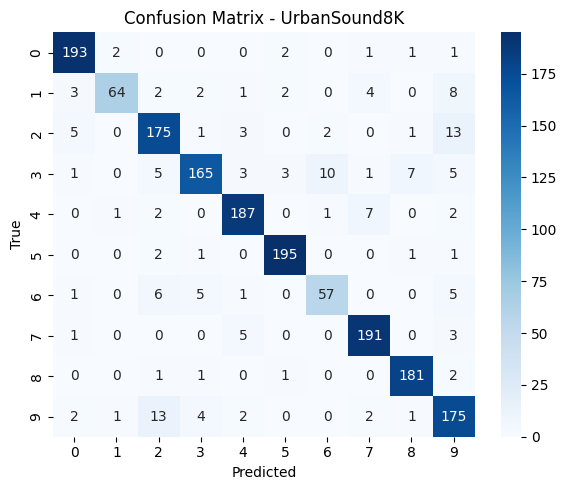


===== ESC-50 =====
Shape: (2000, 13)
Số class: 50
Train size: 1600
Test size: 400
Accuracy: 0.43

Classification Report:
                  precision    recall  f1-score   support

        airplane       0.38      0.38      0.38         8
       breathing       0.33      0.12      0.18         8
  brushing_teeth       0.17      0.12      0.14         8
     can_opening       0.38      0.38      0.38         8
        car_horn       0.43      0.38      0.40         8
             cat       0.56      0.62      0.59         8
        chainsaw       0.17      0.12      0.14         8
  chirping_birds       0.50      0.50      0.50         8
    church_bells       0.50      0.38      0.43         8
        clapping       0.67      0.75      0.71         8
     clock_alarm       0.71      0.62      0.67         8
      clock_tick       0.14      0.12      0.13         8
        coughing       0.23      0.38      0.29         8
             cow       0.33      0.12      0.18         8
  crack

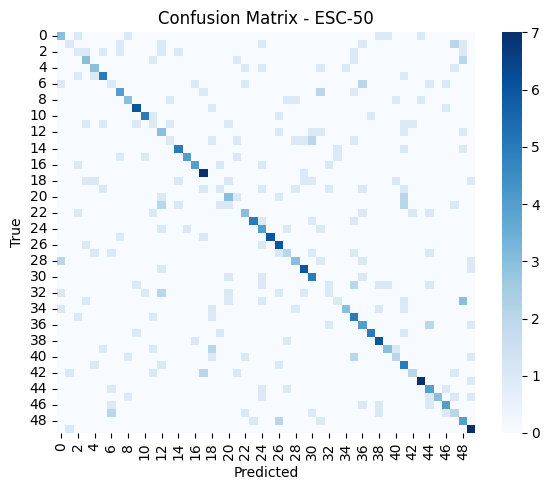

In [51]:
acc_urban = run_knn(X_urban, y_urban, "UrbanSound8K", k=k_urban)
acc_esc50 = run_knn(X_esc50, y_esc50, "ESC-50", k=k_esc50)

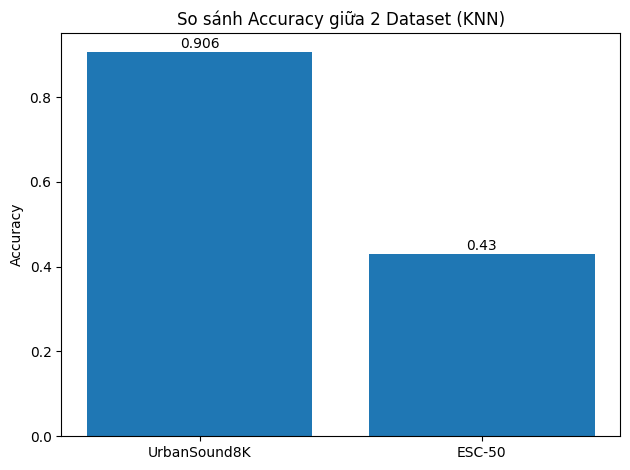

In [52]:
datasets = ["UrbanSound8K", "ESC-50"]
accuracies = [acc_urban, acc_esc50]

plt.figure()
plt.bar(datasets, accuracies)
plt.title("So sánh Accuracy giữa 2 Dataset (KNN)")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.tight_layout()
plt.show()

In [53]:
print("\n===== KẾT LUẬN =====")

if acc_urban > acc_esc50:
    print(f"UrbanSound8K tốt hơn (Accuracy = {round(acc_urban,3)})")
else:
    print(f"ESC-50 tốt hơn (Accuracy = {round(acc_esc50,3)})")


===== KẾT LUẬN =====
UrbanSound8K tốt hơn (Accuracy = 0.906)


In [73]:
# ===== LOAD MODEL =====
model = joblib.load("UrbanSound8K_knn.pkl")
scaler = joblib.load("UrbanSound8K_scaler.pkl")

# ===== EXTRACT FEATURE =====
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050, duration=4)
    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)

    features = np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.mean(mel, axis=1)
    ])

    return features.reshape(1, -1)
# ===== DEMO FILE =====
file_path = r"D:\sound_project\data\fold1\24074-1-0-1.wav"   # đổi thành file của bạn

X_new = extract_features(file_path)

# scale giống lúc train
X_new = scaler.transform(X_new)

# predict
pred = model.predict(X_new)

print("Dự đoán:", pred[0])
proba = model.predict_proba(X_new)
print(proba)

ValueError: X has 153 features, but StandardScaler is expecting 13 features as input.

In [72]:
distances, indices = model.kneighbors(X_new)

print(indices)
print(distances)

[[5955]]
[[200.66615869]]
